# Neural Network (MLP) — Customer Churn Prediction (Telco dataset, v2 preprocessing)

A multi-layer perceptron trained with PyTorch on the Telco customer churn dataset.
The architecture is the one from `churn_prediction_MLP.ipynb`: a small funnel
`46 -> 16 -> 8 -> 1` with ReLU hidden activations and a sigmoid output, trained with
binary cross-entropy and Adam for 50 epochs of batch size 100. The preprocessing
comes from `PreprocessingTelcoV2`, which reproduces that notebook's wrangling exactly.

The pipeline follows the same order as the other notebooks:

1. **Preprocessing** — `PreprocessingTelcoV2`: target encoding, blank `TotalCharges`
   handling, log transform, standardisation, one-hot encoding and split.
2. **Model definition** — the `TelcoMLP` class.
3. **Probability helper** — inference wrapper.
4. **Training function** — one loop that also records per-epoch validation scores.
5. **Training and learning curve** — the fixed configuration.
6. **Threshold selection** — on the validation set, never on test.
7. **Evaluation** — held-out test set, ROC, confusion matrix.

**The preprocessing is now the notebook's, not w1's.** Everything
`churn_prediction_MLP.ipynb` does inline is in `PreprocessingTelcoV2`:

- `Churn` mapped `Yes -> 1` / `No -> 0`.
- `TotalCharges` blanks coerced to NaN, then the 11 affected rows **dropped** rather
  than imputed.
- `MonthlyCharges` and `TotalCharges` log-transformed, then `tenure`,
  `MonthlyCharges` and `TotalCharges` z-scored. `tenure` is not log-transformed.
- `SeniorCitizen` recoded to `'Yes'` / `'No'` so it is one-hot encoded like the rest.
- `pd.get_dummies` over every remaining column with fewer than five unique values.
- Standardisation statistics and the one-hot template come from the **whole cleaned
  dataset**, exactly as in the notebook, so the feature values are identical.

The 46 features and their order match the notebook's `df_trans` one for one. The one
deliberate deviation is the split: the notebook held out a flat 20% for test, while
`PreprocessingTelcoV2` also carves a validation set out of the remainder, because the
threshold below is tuned on validation data. See the notes at the end.

Two implementation notes:

- **PyTorch instead of Keras.** The original uses `keras.Sequential` with
  `input_dim`. `keras`/`tensorflow` are not in `requirements.txt` and are not
  installed in the project environment, which is torch-only, so the same graph is
  expressed with `nn.Sequential`. Layer sizes, activations, loss and optimiser are
  identical, and `predict_proba` returns probabilities just as in the original.
- **No hyper-parameter search.** The original fixed the architecture by hand, so
  there is no Optuna study here either. Everything that was searched in the previous
  version of this notebook is now decided in advance, which is the point of the
  comparison.

**Why the validation split matters.** It is what the learning curve is plotted
against and what the decision threshold is tuned on. The original notebook used the
default 0.5 cut; section 8 shows why that is a poor choice on a 26.5% churn rate.

## 1. Imports and global settings

Neural network training has more sources of randomness than the other models
(weight initialisation, batch shuffling), so the seed is set for NumPy and PyTorch
explicitly.

The device is detected rather than hard-coded, so the notebook runs on a machine
without a GPU.

`BATCH_SIZE` and `EPOCHS` are kept at the values the original configuration used.
On ~4,900 training rows a batch of 100 means roughly 49 updates per epoch, so 50
epochs is about 2,450 updates — short for a network this small, which is why the
learning curve in section 5 is worth reading before trusting the final numbers.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
BATCH_SIZE = 100
EPOCHS = 50
LEARNING_RATE = 1e-3

np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"pandas {pd.__version__}")
print(f"torch {torch.__version__}")
print(f"Device: {DEVICE}")

pandas 3.0.6
torch 2.7.1+cu126
Device: cpu


## 2. Load and preprocess the dataset

The full pipeline lives in `PreprocessingTelcoV2`, in this same `w2` package. The
notebook only consumes the ready-to-model splits.

The transformations follow `churn_prediction_MLP.ipynb`: the charge columns are
log-transformed before being z-scored, `tenure` is only z-scored, and the categorical
columns are one-hot encoded with `pd.get_dummies`. All 46 resulting columns are on
consistent scales, which gradient descent needs.

**A caveat worth stating.** The notebook standardises *before* splitting, so the mean
and standard deviation of `tenure`, `MonthlyCharges` and `TotalCharges` are computed
over the whole cleaned dataset. `PreprocessingTelcoV2` reproduces that by default
(`fit_scalers_on_train_only = False`). It is a mild form of leakage: the training rows
see a little information from the validation and test rows through the scaling
constants. Setting the flag to `True` fits them on training rows only, which is the
correct thing to do and changes the numbers slightly.

`preprocess()` returns the train and test splits and exposes the validation split as
`X_validation` / `y_validation`. That validation split is used here rather than
re-splitting `X_train`, so the threshold in section 8 is chosen on data the model
never trained on.

In [ ]:
from pathlib import Path
import sys

"""
for parent in (Path.cwd(), *Path.cwd().parents):
    if (parent / "w2_neural_networks").is_dir():
        sys.path.insert(0, str(parent))
        break
else:
    raise ModuleNotFoundError("Could not locate the src directory")

from w2_neural_networks.data_preprocessing.data_preprocessing_telco_v2 import (
    PreprocessingTelcoV2,
)
"""

while not (ROOT / "src" / "w1_supervized_learning").is_dir():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("No se encontró src/w1_supervized_learning")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

from w1_supervized_learning.data_preprocessing.data_preprocessing_telco import (
    PreprocessingTelco,
)


prep = PreprocessingTelco()
X_train, X_test, y_train, y_test = prep.preprocess()
FEATURE_NAMES = prep.feature_names

X_val = prep.X_validation
y_val = prep.y_validation

y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

N_FEATURES = X_train.shape[1]
WEIGHT_RATIO = float((y_train == 0).sum() / (y_train == 1).sum())

print(f"Train: {X_train.shape}  churn rate {y_train.mean():.1%}")
print(f"Val:   {X_val.shape}  churn rate {y_val.mean():.1%}")
print(f"Test:  {X_test.shape}  churn rate {y_test.mean():.1%}")
print(f"Negative/positive ratio in train: {WEIGHT_RATIO:.2f}")
print(f"Splits: {prep.split_sizes}")
print(f"Rows dropped: {prep.rows_dropped}   TotalCharges missing: {prep.total_charges_missing}")

Train: (4570, 46)  churn rate 26.6%
Val:   (1055, 46)  churn rate 26.5%
Test:  (1407, 46)  churn rate 26.6%
Negative/positive ratio in train: 2.76
Splits: {'train': 4570, 'validation': 1055, 'test': 1407}
Rows dropped: 11   TotalCharges missing: 11


## 3. Move the data to tensors

The validation and test sets are small enough to live on the device as single tensors,
so they can be evaluated in one forward pass instead of being batched.

`float32` is used throughout: it is the default precision for network weights, and
mixing in `float64` inputs would raise a dtype error at the first matrix multiply.

The training set stays on the CPU in a `DataLoader`, which batches it on demand.

In [3]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

print(f"X_train_t: {tuple(X_train_t.shape)}  dtype {X_train_t.dtype}")
print(f"X_val_t:   {tuple(X_val_t.shape)}  on {X_val_t.device}")
print(f"Input features: {N_FEATURES}")

X_train_t: (4570, 46)  dtype torch.float32
X_val_t:   (1055, 46)  on cpu
Input features: 46


## 4. Model definition: `TelcoMLP`

`46 -> 16 -> 8 -> 1`, ReLU after each hidden layer, sigmoid on the output. This is the
architecture from `churn_prediction_MLP.ipynb`, with the input width adapted from
`len(features)` to the 46 columns this preprocessing produces.

**The output layer has a sigmoid on purpose**, unlike the previous version of this
notebook. The original model ends in `Dense(1, activation='sigmoid')` and is compiled
with `binary_crossentropy`, so `BCELoss` is the matching PyTorch choice here. Keeping
the same pairing is what makes the numbers in section 9 comparable to the original.

The cost is numerical stability: `BCELoss` computes `log(p)` on a sigmoid output, and
a saturated output can produce a very large gradient. With 50 epochs at a 1e-3
learning rate and standardised inputs that stays well inside safe territory, and the
learning curve in section 7 is the check on it.

In [4]:
class TelcoMLP(nn.Module):
    """Multilayer perceptron sized after churn_prediction_MLP.ipynb: 46 -> 16 -> 8 -> 1.

    Args:
        input_dim (int): Number of input features
        hidden_dims (list): List of hidden layer sizes [h1, h2, ...]
    """

    def __init__(self, input_dim, hidden_dims=(16, 8)):
        super(TelcoMLP, self).__init__()

        self.input_dim = input_dim
        self.hidden_dims = list(hidden_dims)

        layers = []
        prev_dim = input_dim

        for hidden_dim in self.hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

    def count_parameters(self):
        """Count total number of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model = TelcoMLP(input_dim=N_FEATURES)
print(model)
print(f"Trainable parameters: {model.count_parameters():,}")

TelcoMLP(
  (network): Sequential(
    (0): Linear(in_features=46, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Trainable parameters: 897


## 5. Probability helper

`model.eval()` matters: it switches any module that behaves differently between
training and evaluation into inference mode. `torch.no_grad()` skips building the
autograd graph, which is unnecessary for inference and saves memory.

The model already ends in a sigmoid, so this is a straight pass-through. It is kept as
a function because the original notebook called `model.predict(X_test)` in three
separate places, and centralising it is what lets the evaluation cells below stay
short. It comes before training because the training loop scores validation with it
every epoch.

In [5]:
def predict_proba(model: nn.Module, X_tensor: torch.Tensor) -> np.ndarray:
    """Return churn probabilities for a tensor already on the target device."""
    model.eval()
    with torch.no_grad():
        return model(X_tensor).squeeze(1).cpu().numpy()

## 6. Training function

One loop, recording the validation score every epoch so the learning curve in the next
section can be plotted. There is no search to feed, so the loop is a plain
epoch/batch iteration.

`Adam` at the default learning rate of 1e-3, matching `optimizer='adam'` in the
original, and no class weighting — `BCELoss` weights both classes equally, which is
the honest counterpart to not passing `class_weight` in Keras.

Seeding is inside the function rather than only global, so a repeated call reproduces
the same weights.

In [6]:
def train_model(epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE, seed=SEED):
    """Train a TelcoMLP, scoring validation average precision every epoch."""
    torch.manual_seed(seed)
    generator = torch.Generator().manual_seed(seed)

    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        drop_last=False,
    )

    net = TelcoMLP(input_dim=N_FEATURES).to(DEVICE)

    optimizer = optim.Adam(net.parameters(), lr=lr)
    criterion = nn.BCELoss()

    history = {"loss": [], "val_average_precision": []}

    for epoch in range(epochs):
        net.train()
        epoch_loss = 0.0

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE).reshape(-1, 1)

            optimizer.zero_grad()
            probs = net(X_batch)
            loss = criterion(probs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(X_batch)

        history["loss"].append(epoch_loss / len(dataset))
        history["val_average_precision"].append(
            float(average_precision_score(y_val, predict_proba(net, X_val_t)))
        )

    return net, history

## 7. Training and learning curve

Validation average precision and training loss per epoch. What to look for:

- **Still rising at the end** — 50 epochs was not enough. The original configuration
  was fitted on 5,626 rows after a `train_test_split(test_size=0.2)`; here the same
  50 epochs sit on ~4,570 rows, a slightly smaller matrix.
- **Rises then falls** — overfitting, and more epochs would hurt.
- **Flat from the start** — the learning rate is too low, or the network too small to
  fit the signal.

Two windows are plotted side by side because on a 26.5% churn rate they tell different
halves of the story: loss measures whether the probabilities are calibrated, average
precision measures whether the customers are *ranked* correctly, which is what the
threshold in section 8 will later cut.

epoch   1  loss 0.6427  val AP 0.6066
epoch  26  loss 0.3983  val AP 0.6563
epoch  50  loss 0.3945  val AP 0.6528


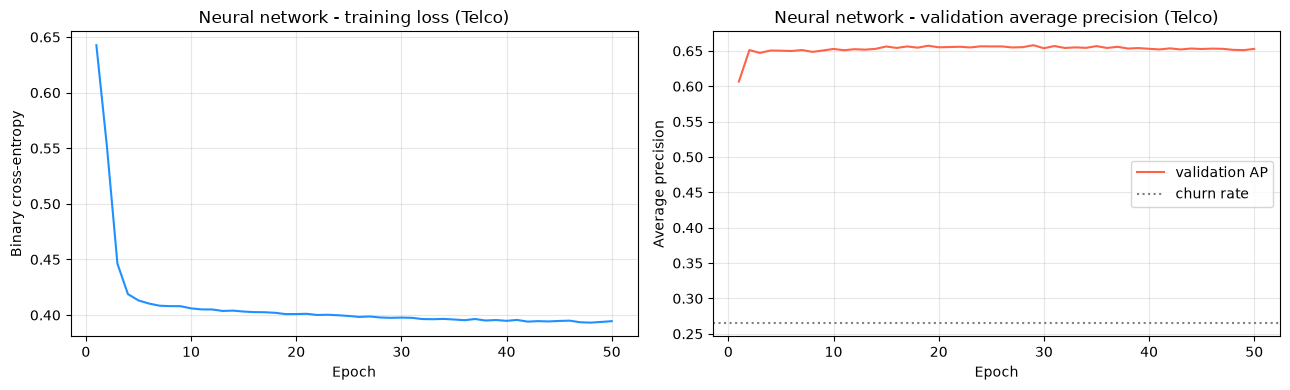

CPU times: user 16.7 s, sys: 411 ms, total: 17.2 s
Wall time: 8.08 s


In [7]:
%%time
final_model, history = train_model()

for epoch in (0, EPOCHS // 2, EPOCHS - 1):
    print(
        f"epoch {epoch + 1:>3}  "
        f"loss {history['loss'][epoch]:.4f}  "
        f"val AP {history['val_average_precision'][epoch]:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, EPOCHS + 1), history["loss"], color="dodgerblue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].set_title("Neural network - training loss (Telco)")
axes[0].grid(alpha=0.3)

axes[1].plot(
    range(1, EPOCHS + 1),
    history["val_average_precision"],
    color="tomato",
    label="validation AP",
)
axes[1].axhline(y_test.mean(), color="grey", linestyle=":", label="churn rate")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Average precision")
axes[1].set_title("Neural network - validation average precision (Telco)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Threshold selection on the validation set

The sigmoid output is a probability; turning it into a decision needs a cut. The
default 0.5 is arbitrary, and it is particularly unsuited to a dataset where only
26.5% of customers churn: a model that is uncertain about most of its predictions
will still clear 0.5 for too few of them.

The cut is chosen on **validation**, which the model never trained on. The original
notebook used 0.5 and reported precision and recall around 0.69; the point of this
section is to show what that default costs.

Best threshold: 0.29  (validation F1 = 0.6126)
F1 at the default 0.50: 0.5100


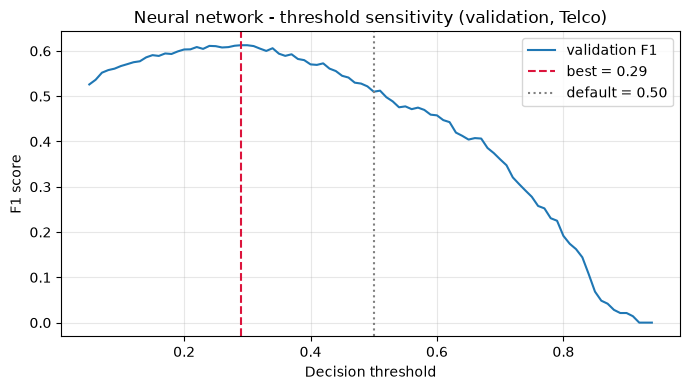

In [8]:
val_proba = predict_proba(final_model, X_val_t)

thresholds = np.arange(0.05, 0.95, 0.01)
val_f1 = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]

best_threshold = float(thresholds[int(np.argmax(val_f1))])
print(f"Best threshold: {best_threshold:.2f}  (validation F1 = {max(val_f1):.4f})")
print(f"F1 at the default 0.50: {f1_score(y_val, (val_proba >= 0.5).astype(int)):.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, val_f1, label="validation F1")
ax.axvline(best_threshold, color="crimson", linestyle="--", label=f"best = {best_threshold:.2f}")
ax.axvline(0.5, color="grey", linestyle=":", label="default = 0.50")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("F1 score")
ax.set_title("Neural network - threshold sensitivity (validation, Telco)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Evaluation on the test set

The test set is touched exactly once, here.

Metrics are ordered from most to least informative for this problem.
`average_precision` and `roc_auc` judge the ranking and are threshold-free; `f1`,
`recall` and `precision` judge the decisions at the chosen cut.

Churn is 26.5% positive, so `accuracy` flatters the model: predicting every customer
as staying already scores 73.5%. `balanced_accuracy` is the metric that does not move
when the threshold shifts, and the gap between the two is the size of that flattering.

In [9]:
test_proba = predict_proba(final_model, X_test_t)
test_preds = (test_proba >= best_threshold).astype(int)

metrics = {
    "average_precision": average_precision_score(y_test, test_proba),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "f1": f1_score(y_test, test_preds),
    "recall": recall_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_preds),
    "accuracy": accuracy_score(y_test, test_preds),
}

print(f"Threshold used: {best_threshold:.2f}")
print(f"Accuracy of always predicting 'stays': {max(y_test.mean(), 1 - y_test.mean()):.4f}")
print()
pd.Series(metrics, name="neural_network").to_frame().round(4)

Threshold used: 0.29
Accuracy of always predicting 'stays': 0.7342



,neural_network
average_precision,0.6485
roc_auc,0.8469
f1,0.6417
recall,0.7112
precision,0.5846
balanced_accuracy,0.7641
accuracy,0.7889


## 10. ROC curve

Included because the original notebook reported ROC-AUC as its headline number, and
because it is threshold-free: it shows whether the ranking is good independently of
where the cut ends up. Both splits are plotted so overfitting is visible.

AUC for train set: 0.8658
AUC for test set:  0.8469


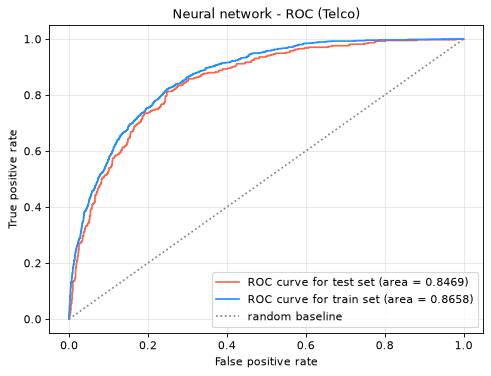

In [10]:
train_proba = predict_proba(final_model, X_train_t)

train_fpr, train_tpr, _ = roc_curve(y_train, train_proba)
test_fpr, test_tpr, _ = roc_curve(y_test, test_proba)

train_roc_auc = auc(train_fpr, train_tpr)
test_roc_auc = auc(test_fpr, test_tpr)

print(f"AUC for train set: {train_roc_auc:.4f}")
print(f"AUC for test set:  {test_roc_auc:.4f}")

plt.figure(figsize=(7, 5), dpi=80)
plt.plot(
    test_fpr,
    test_tpr,
    color="tomato",
    label="ROC curve for test set (area = %0.4f)" % test_roc_auc,
)
plt.plot(
    train_fpr,
    train_tpr,
    color="dodgerblue",
    label="ROC curve for train set (area = %0.4f)" % train_roc_auc,
)
plt.plot([0, 1], [0, 1], color="grey", linestyle=":", label="random baseline")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Neural network - ROC (Telco)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 11. Confusion matrix

The business reading of the two error types:

- **False negatives** — churners the model missed. Direct lost revenue.
- **False positives** — loyal customers flagged as at-risk. The cost of a wasted
  retention offer.

Which one hurts more depends on the margin per customer versus the cost of the offer,
and that is exactly the trade-off the threshold in section 8 controls. A matrix
skewed heavily towards one error type means the threshold is not doing its job.

In [11]:
tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()

pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["actual: stays", "actual: churns"],
    columns=["predicted: stays", "predicted: churns"],
)

,predicted: stays,predicted: churns
actual: stays,844,189
actual: churns,108,266


## 12. Notes and limitations

**What this notebook establishes.** The `churn_prediction_MLP.ipynb` architecture,
trained on `PreprocessingTelcoV2` — the notebook's own preprocessing, packaged as a
class — with an honestly selected decision threshold.

**Limitations.**

- **Standardisation leaks across the split.** `PreprocessingTelcoV2` reproduces the
  original's pre-split z-scoring, so the scaling constants were computed over the
  whole dataset (see section 2). It is mild, but it means the reported scores are
  slightly optimistic. Set `fit_scalers_on_train_only = True` for a clean version.
- **Fixed architecture, no search.** Layers, widths, learning rate, epochs and batch
  size are inherited by hand. Nothing here shows they are the right ones for this
  data, only that they work reasonably.
- **50 epochs may not be enough.** Check the learning curve in section 7. If the
  validation line is still climbing at the last epoch, the reported score is a lower
  bound and a longer run would likely improve it.
- **Small validation set.** ~1,055 rows, of which about 280 are churners. The chosen
  threshold is picked on that, so it is noisy; a flat validation F1 curve near the
  optimum in section 8 is the honest reading.
- **No interpretability.** There are no feature importances or coefficients to report.
  Attribution would need a dedicated method such as integrated gradients or SHAP.
- **Neural networks are rarely the right tool for tabular data**, even at this size.
  Gradient-boosted trees are the usual state of the art in this regime. If this
  notebook loses to XGBoost, that is the expected result and worth reporting as a
  finding rather than a failure.